# The third leg: model snowfall against the gauges and EarthCARE

The two other legs of this project are in place — EarthCARE's retrieved
snowfall along the track, and DMI's hourly gauges at four coastal stations.
This notebook adds the **model leg**: hourly ERA5 snowfall for all of 2025 at
each station, and asks the same *event* questions the other notebooks ask —
does it snow at the same hours as the gauge, does EarthCARE agree better with
a model cell than with a point gauge, and at each overpass do the three
sources agree that it is snowing?

## What the model data is, and is not

**ERA5 25 km** (`era5`) — ECMWF's fifth-generation reanalysis (Hersbach et
al. 2020), 0.25° grid, hourly — from the keyless open-meteo Historical
Weather API (fetch script: `notebooks/fetch_model_snowfall.py`; data:
`data/model/`). It is the standard reference reanalysis and the forcing of
every regional Greenland model, which is why it is the one kept here.

The regional Greenland models that would resolve the fjord coastlines were
all ruled out: MAR v3.14 publishes only daily and monthly files (Fettweis et
al. 2017), RACMO2.3p2 output is not public for 2025 (Noël et al. 2018), DMI's
own 2 km HARMONIE keeps only 24–48 h of history, Met Norway's AROME-Arctic
archive stops at 18°W, and CARRA2 (the 2.5 km pan-Arctic reanalysis) needs a
Copernicus account and hours of queue plus forecast-accumulation bookkeeping.

## Conventions that make the join exact

- **Stamps.** open-meteo reports each hour's value as the sum over the
  *preceding* hour, stamped at the hour end — exactly DMI's convention for
  parameter 601 (covering interval (stamp − 1 h, stamp]). Model and gauge
  therefore join on the timestamp with no shifting.
- **Precision.** ERA5 is stored at 0.1 mm, the same floor as the gauge, so
  "model snowing" (> 0) is identical to (≥ 0.1 mm/h) and the θ = 0.1 mm/h
  harmonization of the other notebooks carries over unchanged — including to
  the FSS section, where the satellite is scored against the model on exactly
  the threshold logic used against the gauge.
- **Phase.** The model side uses its own solid-precipitation variable
  (`snowfall_water_equivalent`, mm w.e.); the gauge side keeps the
  T ≤ 1.5 °C proxy used everywhere else in the project.
- **One cell per station.** open-meteo's `cell_selection=land` picks a *land*
  grid cell with an elevation similar to the station's (90 m DEM), 2.5–23.5 km
  away for ERA5. This is the model leg's own geometry caveat: neighbouring
  cells differ by up to ~27 % in annual snow, and a 25 km cell is itself a
  small neighbourhood, so the model is expected to snow *more often* than a
  point gauge that reads to 0.1 mm.

Inherited from the other notebooks: EarthCARE profiles must be converged,
< 20 mm/h, read at 1000 m AGL; overpasses are counted within 100 km of a
gauge; Ittoqqortoormiit's gauge is masked before 2025-05-01 (commissioning
artefacts). Sections: **1** load and align, **2** ERA5 against the gauge hour
by hour, **3** ERA5 against EarthCARE across spatial scales (FSS), **4** the
three sources at the overpasses, **5** takeaways.

## 1 · Load: four stations, their EarthCARE overpasses, and the ERA5 series

The gauge and satellite side is the loader of `compare_earthcare_dmi_stations`
(same constants, same per-overpass table), keeping the per-profile arrays that
section 3 needs to rebuild neighbourhoods at any radius. The model side is
read from the fetched CSV and checked for exact alignment with the gauge
stamps.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

sys.path.insert(0, "../src")
from collocation import load_site
from gauges import daily_snow, snow_window_stats
from study_config import (SNOW_THRESHOLD_MMHR, STATIONS, THETA_ADJUSTED,
                          THETA_FSS)
from validation import (contingency, fss_pairs, fss_score, point_fss,
                        useful_fss)

# --- the single model leg ---
MODEL_ID = "era5"
MODEL_LABEL = "ERA5 25 km"
MODEL_COLOR = "#756bb1"
GAUGE_COLOR, SAT_COLOR = "0.35", "#2171b5"

# --- one site dict per station: gauge frame + snow series, per-profile
#     satellite arrays, and the standard per-overpass table (src/collocation) ---
sites = {}
for site_name, station in STATIONS.items():
    site = load_site(station)
    sites[site_name] = site
    overpass_table = site["overpasses"]
    n_with_gauge = int((overpass_table.gauge_n_stamps_pm30 > 0).sum())
    print(f"{site_name:<18} overpasses <=100 km: {len(overpass_table):>3} "
          f"(with gauge data in window: {n_with_gauge:>3}) | "
          f"satellite snowing: {int(overpass_table.sat_any_100km.sum()):>3} | "
          f"gauge snowing: {int((overpass_table.gauge_snow_pm30_mm > 0).sum()):>3}")

# --- model side: hourly ERA5 snowfall at the elevation-matched land cell ---
model_long = pd.read_csv("../data/model/openmeteo_hourly_2025.csv", parse_dates=["ts"])
model_cells = pd.read_csv("../data/model/openmeteo_cells_2025.csv")
assert set(model_long["model"]) == {MODEL_ID}, set(model_long["model"])

print(f"\n{MODEL_LABEL} aligned on the gauge stamps:")
for site_name, site in sites.items():
    rows = model_long[model_long.site == site_name]
    model_hourly = rows.drop(columns=["site", "model"]).set_index("ts").sort_index()
    site["model_hourly"] = model_hourly
    site["model_snow_mmhr"] = model_hourly["snowfall_mm"]
    # --- alignment guards: complete hourly year, gauge stamps are a subset,
    #     and the 0.1 mm floor that makes "> 0" the same test as the gauge's ---
    steps = model_hourly.index.to_series().diff().dropna()
    assert len(model_hourly) == 8760 and (steps == pd.Timedelta("1h")).all()
    assert site["station_hourly"].index.isin(model_hourly.index).all()
    smallest_positive = model_hourly.loc[model_hourly.snowfall_mm > 0, "snowfall_mm"].min()
    assert np.isclose(smallest_positive, 0.1), smallest_positive
    # totals are compared on the gauge-valid hours only (the model has no gaps)
    gauge_valid = site["gauge_snow_mmhr"].notna()
    model_on_valid = site["model_snow_mmhr"].reindex(gauge_valid.index)[gauge_valid].sum()
    print(f"  {site_name:<18} gauge-valid hours {int(gauge_valid.sum()):>5} / 8760 | "
          f"snow w.e. on those hours: gauge {site['gauge_snow_mmhr'].sum():6.1f} mm, "
          f"{MODEL_LABEL} {model_on_valid:6.1f} mm")
display(model_cells.round(3))

# --- eyeball check of one known event: Aasiaat 2025-03-14 (9.1 mm gauge snow day) ---
day = slice("2025-03-14 00:00", "2025-03-15 00:00")
aasiaat = sites["aasiaat"]
event_check = pd.DataFrame({"gauge_snow_mm": aasiaat["gauge_snow_mmhr"].loc[day],
                            MODEL_LABEL: aasiaat["model_snow_mmhr"].loc[day]})
print(f"\nAasiaat 2025-03-14, hourly snow w.e. (mm) -- gauge vs {MODEL_LABEL} "
      "on the same stamps:")
print(event_check[event_check.sum(axis=1) > 0].to_string())

aasiaat            overpasses <=100 km: 118 (with gauge data in window: 118) | satellite snowing:  58 | gauge snowing:  22


nuuk               overpasses <=100 km: 103 (with gauge data in window: 102) | satellite snowing:  65 | gauge snowing:   9


tasiilaq           overpasses <=100 km: 103 (with gauge data in window:  72) | satellite snowing:  70 | gauge snowing:   4


ittoqqortoormiit   overpasses <=100 km: 121 (with gauge data in window:  67) | satellite snowing:  68 | gauge snowing:   5

ERA5 25 km aligned on the gauge stamps:
  aasiaat            gauge-valid hours  7852 / 8760 | snow w.e. on those hours: gauge  134.4 mm, ERA5 25 km  107.8 mm
  nuuk               gauge-valid hours  8620 / 8760 | snow w.e. on those hours: gauge  391.1 mm, ERA5 25 km  376.7 mm
  tasiilaq           gauge-valid hours  6759 / 8760 | snow w.e. on those hours: gauge  138.3 mm, ERA5 25 km  282.7 mm
  ittoqqortoormiit   gauge-valid hours  5940 / 8760 | snow w.e. on those hours: gauge  168.2 mm, ERA5 25 km  407.8 mm


,site,model,cell_lat,cell_lon,cell_elev_m,offset_km,station_lat,station_lon
0,aasiaat,era5,68.50,-52.75,38.0,23.5,68.708,-52.852
1,nuuk,era5,64.25,-51.75,78.0,7.5,64.183,-51.731
2,tasiilaq,era5,65.75,-37.75,24.0,16.3,65.611,-37.637
3,ittoqqortoormiit,era5,70.50,-22.00,61.0,2.5,70.484,-21.951



Aasiaat 2025-03-14, hourly snow w.e. (mm) -- gauge vs ERA5 25 km on the same stamps:
                     gauge_snow_mm  ERA5 25 km
ts                                            
2025-03-14 00:00:00            0.6         0.3
2025-03-14 01:00:00            1.4         0.4
2025-03-14 02:00:00            3.0         1.0
2025-03-14 03:00:00            0.3         0.6
2025-03-14 04:00:00            0.1         0.4
2025-03-14 05:00:00            0.0         0.1
2025-03-14 06:00:00            2.8         0.0
2025-03-14 07:00:00            0.3         0.0
2025-03-14 08:00:00            0.2         0.0
2025-03-14 09:00:00            0.2         0.0
2025-03-14 11:00:00            0.1         0.0
2025-03-14 15:00:00            0.1         0.0


## 2 · ERA5 against the gauge: hourly events over 2025

Here there is **no geometry problem** — the model cell sits on the station —
so every disagreement is timing, sub-grid variability, or the gauge itself.
The comparison is scored only on hours where the gauge has a valid reading
(the model has none missing), with the gauge as the reference:

- **hit** — both snowing; **miss** — gauge snowing, model dry; **false
  alarm** — model snowing, gauge dry; **correct negative** — both dry;
  POD = hit / (hit + miss), FAR = false alarm / (hit + false alarm), and the
  **frequency bias** (hit + false alarm) / (hit + miss) says how much more
  often the model snows than the gauge.
- Two criteria: the **exact hour**, and a **±1 h tolerance** where the
  model counts as snowing if any of the three hours centred on the stamp
  snows — the lenient view that forgives an hour of timing error (the
  analogue of the ±90 min sensitivity in the events notebook). The tolerant
  criterion inflates the model's event count by construction, so read its
  frequency bias accordingly.

**The FSS column.** Section 3 scores the satellite against each reference
over neighbourhoods of growing radius. Here there is nothing to grow: one
model cell against one station is a single pair of points, so the same
Fractions Skill Score collapses to its **point-scale limit** — a single
number per row rather than a curve. With binary hourly flags it reduces to
2·hit / (2·hit + miss + false alarm), the Dice/F1 score, which is useful
precisely because it folds POD and FAR into one figure: a model can buy POD
with false alarms, and FSS will not reward it. It is read against
`FSS_useful` = 0.5 + f₀/2 in the adjacent column, the same yardstick used
throughout section 3, where f₀ is the gauge's base rate over the scored
hours. Note what this is *not*: section 3 scores the **satellite** against a
reference, whereas this column scores the **model** against the gauge, over
the whole year rather than the overpass windows. Same metric and same
yardstick, so the numbers sit on a common scale — but this is a different
pair, not the L → 0 point of those curves. Its closest counterpart is the
`ERA5 vs gauge` row of section 4, which is the same pair restricted to the
overpass windows.

**The pooled row.** `all stations` scores every scored hour — and, in the
daily table below, every scored day — of the four stations as one sample
rather than averaging the four site scores. The records are very unequal
(Nuuk contributes 8 620 valid hours, Ittoqqortoormiit 5 940 after its
commissioning mask), so a per-site mean would over-weight the short, noisy
east-coast records; pooling weights each observation equally instead.

Both the FSS column and the pooled row are repeated on the **daily** table
further down, where the aggregation to whole days raises the gauge's base
rate and therefore the useful-skill bar as well as the score.

What to expect: a 25 km cell snows more often than a point that reads to
0.1 mm, and the gauge undercatches snow in wind (60–90 % catch at ~5 m/s;
Kochendorfer et al. 2017), so a frequency bias above 1 and a non-zero FAR are
partly the gauge missing real snow, not only the model over-producing it.

**What the column shows.** Every row lands **below** its useful-skill line
(FSS 0.34–0.49 against a yardstick of 0.52–0.54): at the hourly point scale
the ERA5 cell and the gauge do not agree well enough to call it skill,
pooled FSS 0.408. More interesting is what happens to the **±1 h
tolerance** — it raises pooled POD from 0.60 to 0.65, which looks like an
improvement, while FSS *falls* from 0.408 to 0.391 and does so at every
station. The tolerance buys hits with disproportionately more false alarms
(2 505 → 3 111), and a symmetric score refuses to pay for that. This is
exactly why the column is worth carrying next to POD and FAR.

In [2]:
# contingency, fss_score, point_fss and useful_fss come from src/validation.py;
# useful_fss takes the base rate, so the gauge flags pass through np.mean first

CRITERIA = ["exact hour", "±1 h tolerance"]

# --- hourly contingency per site, exact hour and +/-1 h tolerance ---
hourly_rows = []
pooled_flags = {criterion: {"model": [], "gauge": []} for criterion in CRITERIA}
for site_name, site in sites.items():
    gauge = site["gauge_snow_mmhr"]
    gauge_valid = gauge.notna()
    gauge_snowing = (gauge > 0)[gauge_valid].values
    model = site["model_snow_mmhr"]
    # tolerance is computed on the gap-free model index, then read at the gauge stamps
    model_exact = (model > 0).reindex(gauge.index)
    model_tolerant = (model.rolling(3, center=True, min_periods=1).max() > 0).reindex(gauge.index)
    for criterion, model_flags in zip(CRITERIA, [model_exact, model_tolerant]):
        model_snowing = model_flags[gauge_valid].astype(bool).values
        counts = contingency(model_snowing, gauge_snowing)
        hourly_rows.append(dict(
            site=site_name, criterion=criterion,
            n_hours=int(gauge_valid.sum()),
            gauge_events=int(gauge_snowing.sum()),
            model_events=int(model_snowing.sum()), **counts,
            freq_bias=round((counts["hit"] + counts["false_alarm"])
                            / max(counts["hit"] + counts["miss"], 1), 2),
            FSS=round(point_fss(model_snowing, gauge_snowing), 3),
            FSS_useful=round(useful_fss(np.mean(gauge_snowing)), 3)))
        # keep the flags so the four stations can be scored as one sample below
        pooled_flags[criterion]["model"].append(model_snowing)
        pooled_flags[criterion]["gauge"].append(gauge_snowing)

# --- one pooled row per criterion: every scored hour of the four stations
#     treated as a single sample, so the small east-coast records do not carry
#     the same weight as Nuuk's near-complete year ---
for criterion in CRITERIA:
    model_all = np.concatenate(pooled_flags[criterion]["model"])
    gauge_all = np.concatenate(pooled_flags[criterion]["gauge"])
    counts = contingency(model_all, gauge_all)
    hourly_rows.append(dict(
        site="all stations", criterion=criterion, n_hours=len(gauge_all),
        gauge_events=int(gauge_all.sum()), model_events=int(model_all.sum()),
        **counts,
        freq_bias=round((counts["hit"] + counts["false_alarm"])
                        / max(counts["hit"] + counts["miss"], 1), 2),
        FSS=round(point_fss(model_all, gauge_all), 3),
        FSS_useful=round(useful_fss(np.mean(gauge_all)), 3)))

hourly_detection = pd.DataFrame(hourly_rows)
pd.set_option("display.width", 240)

# --- save the pooled point-scale score: section 3f of
#     compare_earthcare_dmi_stations plots it against the EarthCARE curves ---
POINT_FSS_PATH = Path("../results/era5_gauge_point_fss.csv")
POINT_FSS_PATH.parent.mkdir(parents=True, exist_ok=True)
(hourly_detection[hourly_detection.site == "all stations"]
 [["criterion", "n_hours", "gauge_events", "model_events", "POD", "FAR",
   "freq_bias", "FSS", "FSS_useful"]]
 .to_csv(POINT_FSS_PATH, index=False))
print(f"wrote {POINT_FSS_PATH} (pooled ERA5-vs-gauge point scores) "
      "for the stations notebook, section 3f")

hourly_detection

wrote ..\results\era5_gauge_point_fss.csv (pooled ERA5-vs-gauge point scores) for the stations notebook, section 3f


,site,criterion,n_hours,gauge_events,model_events,hit,miss,false_alarm,correct_neg,POD,FAR,freq_bias,FSS,FSS_useful
0,aasiaat,exact hour,7852,637,569,222,415,347,6868,0.35,0.61,0.89,0.368,0.541
1,aasiaat,±1 h tolerance,7852,637,732,251,386,481,6734,0.39,0.66,1.15,0.367,0.541
2,nuuk,exact hour,8620,605,1281,460,145,821,7194,0.76,0.64,2.12,0.488,0.535
3,nuuk,±1 h tolerance,8620,605,1530,488,117,1042,6973,0.81,0.68,2.53,0.457,0.535
4,tasiilaq,exact hour,6759,293,843,211,82,632,5834,0.72,0.75,2.88,0.371,0.522
5,tasiilaq,±1 h tolerance,6759,293,1014,236,57,778,5688,0.81,0.77,3.46,0.361,0.522
6,ittoqqortoormiit,exact hour,5940,331,933,228,103,705,4904,0.69,0.76,2.82,0.361,0.528
7,ittoqqortoormiit,±1 h tolerance,5940,331,1046,236,95,810,4799,0.71,0.77,3.16,0.343,0.528
8,all stations,exact hour,29171,1866,3626,1121,745,2505,24800,0.60,0.69,1.94,0.408,0.532
9,all stations,±1 h tolerance,29171,1866,4322,1211,655,3111,24194,0.65,0.72,2.32,0.391,0.532


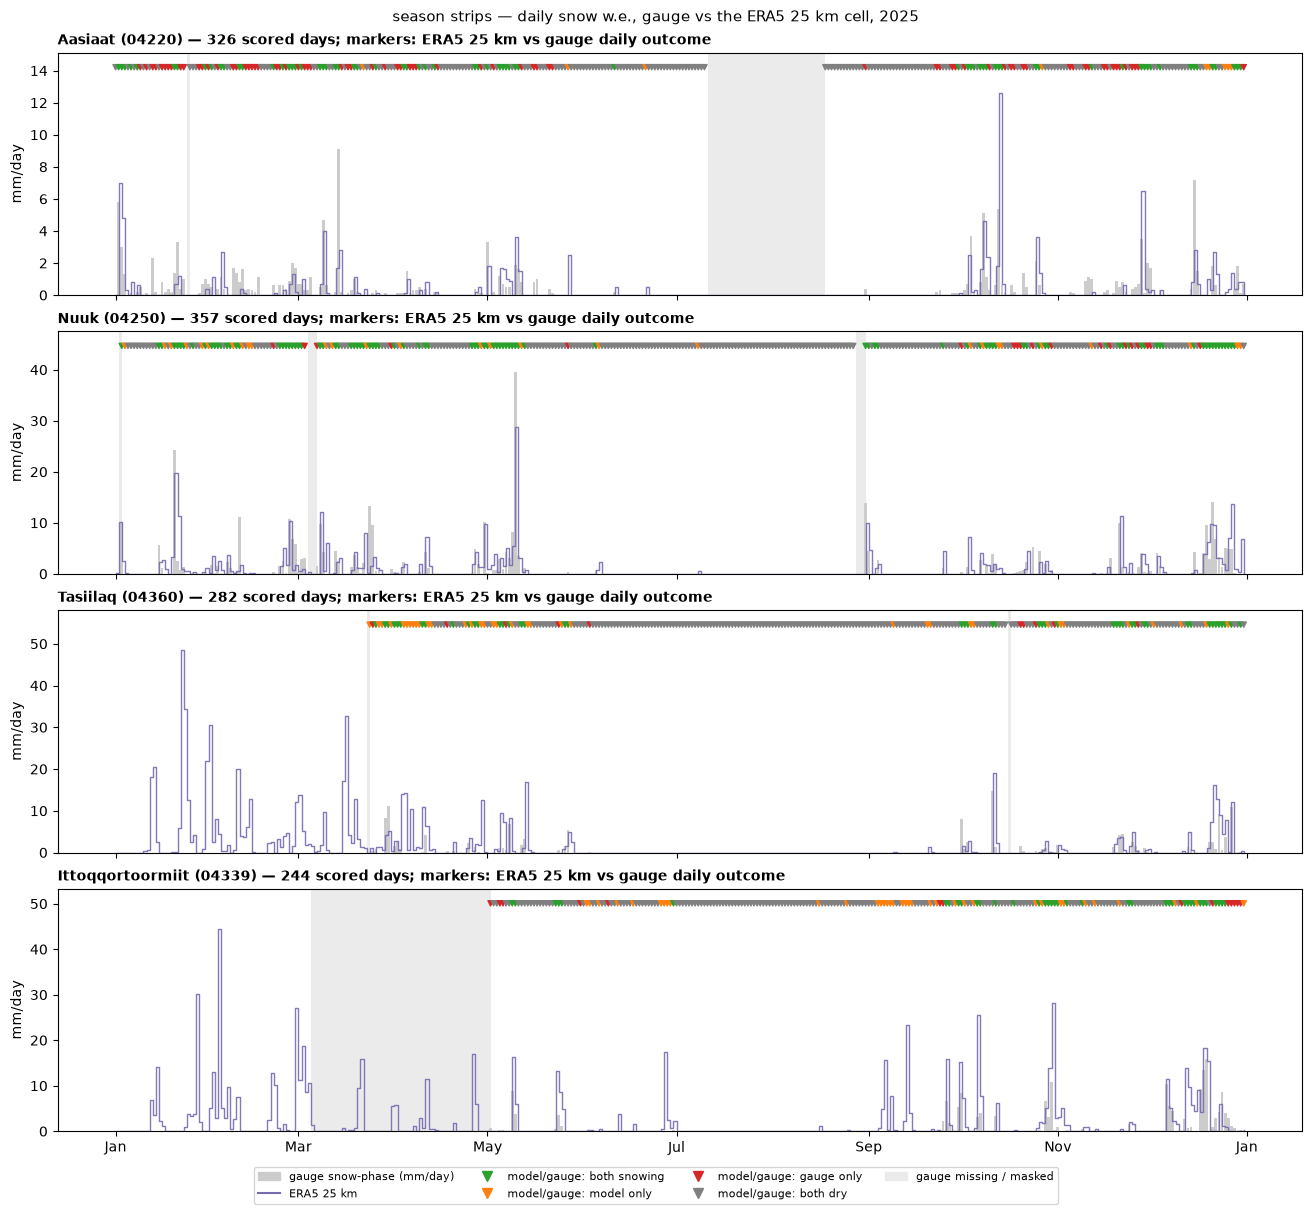

,site,n_days,gauge_snow_days,hit,miss,false_alarm,correct_neg,POD,FAR,FSS,FSS_useful
0,aasiaat,326,141,69,72,9,176,0.49,0.12,0.630,0.716
1,nuuk,357,115,96,19,28,214,0.83,0.23,0.803,0.661
2,tasiilaq,282,56,46,10,36,190,0.82,0.44,0.667,0.599
3,ittoqqortoormiit,244,52,38,14,36,156,0.73,0.49,0.603,0.607
4,all stations,1209,364,249,115,109,736,0.68,0.30,0.690,0.651


In [3]:
# --- daily totals for the strips: gauge days need >= 20 valid hours ---
MIN_VALID_HOURS_PER_DAY = 20
OUTCOME_COLORS = {"both snowing": "tab:green", "model only": "tab:orange",
                  "gauge only": "tab:red", "both dry": "0.5"}


# daily_snow comes from src/gauges.py

# --- plotting the season strips: gauge bars, ERA5 step line, daily outcome ---
fig, axes = plt.subplots(len(sites), 1, figsize=(13, 12), sharex=True,
                         layout="constrained")
for ax, (site_name, site) in zip(axes, sites.items()):
    gauge_daily = daily_snow(site["gauge_snow_mmhr"], MIN_VALID_HOURS_PER_DAY)
    model_daily = daily_snow(site["model_snow_mmhr"])
    strip_ymax = max(np.nanmax(gauge_daily.values), model_daily.max()) * 1.2

    ax.bar(gauge_daily.index, gauge_daily.fillna(0).values, width=0.9, color="0.8",
           label="gauge (snow-phase)")
    ax.step(model_daily.index, model_daily.values, where="post",
            color=MODEL_COLOR, lw=1.0, alpha=0.9, label=MODEL_LABEL)

    # daily outcome of the model vs the gauge on days the gauge is complete enough
    model_on_gauge_days = model_daily.reindex(gauge_daily.index)
    scored_days = gauge_daily.notna()
    gauge_day_snowing = gauge_daily[scored_days] > 0
    model_day_snowing = model_on_gauge_days[scored_days] > 0
    outcome_color = np.where(model_day_snowing & gauge_day_snowing, OUTCOME_COLORS["both snowing"],
                    np.where(model_day_snowing & ~gauge_day_snowing, OUTCOME_COLORS["model only"],
                    np.where(~model_day_snowing & gauge_day_snowing, OUTCOME_COLORS["gauge only"],
                             OUTCOME_COLORS["both dry"])))
    ax.scatter(gauge_daily.index[scored_days], np.full(int(scored_days.sum()), strip_ymax * 0.94),
               c=outcome_color, s=14, marker="v", zorder=5)

    # masked / missing gauge periods, greyed so they are not read as dry days
    for day in gauge_daily.index[~scored_days]:
        ax.axvspan(day, day + pd.Timedelta("1D"), color="0.92", zorder=0, lw=0)

    ax.set_ylim(0, strip_ymax)
    ax.set_ylabel("mm/day")
    ax.set_title(f"{site_name.title()} ({site['station_id']}) — "
                 f"{int(scored_days.sum())} scored days; markers: "
                 f"{MODEL_LABEL} vs gauge daily outcome",
                 loc="left", fontsize=10, fontweight="bold")

# --- shared legend and save ---
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
legend_handles = ([plt.Rectangle((0, 0), 1, 1, color="0.8", label="gauge snow-phase (mm/day)"),
                   plt.Line2D([], [], color=MODEL_COLOR, lw=1.5, label=MODEL_LABEL)]
                  + [plt.Line2D([], [], marker="v", ls="", color=c, ms=7,
                                label=f"model/gauge: {k}")
                     for k, c in OUTCOME_COLORS.items()]
                  + [plt.Rectangle((0, 0), 1, 1, color="0.92", label="gauge missing / masked")])
fig.legend(handles=legend_handles, loc="outside lower center", ncol=4, fontsize=8)
fig.suptitle(f"season strips — daily snow w.e., gauge vs the {MODEL_LABEL} cell, 2025",
             fontsize=11)
fig.savefig("../figures/model_dmi_season_strips.png", dpi=300, bbox_inches="tight")
plt.show()

# --- daily-level contingency vs the gauge (the lenient day view), scored with
#     the same point FSS and useful-skill yardstick as the hourly table ---
daily_rows = []
pooled_days = {"model": [], "gauge": []}
for site_name, site in sites.items():
    gauge_daily = daily_snow(site["gauge_snow_mmhr"], MIN_VALID_HOURS_PER_DAY)
    scored_days = gauge_daily.notna()
    model_daily = daily_snow(site["model_snow_mmhr"]).reindex(gauge_daily.index)
    model_day_snowing = (model_daily[scored_days] > 0).values
    gauge_day_snowing = (gauge_daily[scored_days] > 0).values
    counts = contingency(model_day_snowing, gauge_day_snowing)
    daily_rows.append(dict(site=site_name, n_days=int(scored_days.sum()),
                           gauge_snow_days=int(gauge_day_snowing.sum()), **counts,
                           FSS=round(point_fss(model_day_snowing, gauge_day_snowing), 3),
                           FSS_useful=round(useful_fss(np.mean(gauge_day_snowing)), 3)))
    # keep the flags so the four stations can be scored as one sample below
    pooled_days["model"].append(model_day_snowing)
    pooled_days["gauge"].append(gauge_day_snowing)

# --- the pooled row: every scored day of the four stations as one sample ---
model_all = np.concatenate(pooled_days["model"])
gauge_all = np.concatenate(pooled_days["gauge"])
daily_rows.append(dict(site="all stations", n_days=len(gauge_all),
                       gauge_snow_days=int(gauge_all.sum()),
                       **contingency(model_all, gauge_all),
                       FSS=round(point_fss(model_all, gauge_all), 3),
                       FSS_useful=round(useful_fss(np.mean(gauge_all)), 3)))

daily_detection = pd.DataFrame(daily_rows)
daily_detection

## 3 · ERA5 against EarthCARE: at what scale do they agree?

Section 2 compared the model to a point gauge. This section swaps the
reference and asks the question the FSS analysis of
`compare_earthcare_dmi_stations` asked of the gauge — **at what neighbourhood
radius does EarthCARE's snow detection agree with ERA5?** — using the same
Fractions Skill Score construction (Roberts & Lean 2008; Mittermaier 2014 for
the point-observation flavour), so the two answers are directly comparable.

Per overpass *i* and radius *L*:

- $p_{sat}$ = fraction of usable profiles within *L* km whose rate exceeds θ;
- $p_{ref}$ = fraction of hour-end stamps in the ±1 h window whose snow > 0,
  where the reference is either the gauge or the ERA5 cell — **computed by
  the same function on the same stamps**, so only the reference changes;
- $FSS = 1 - \frac{\sum_i (p_{ref} - p_{sat})^2}{\sum_i p_{sat}^2 + \sum_i p_{ref}^2}$,
  pooled over all four stations, with the usual skill reference
  $FSS_{useful} = 0.5 + f_0/2$ where $f_0$ is the reference's base rate.

**Why this is worth doing.** The stations notebook concluded that EarthCARE
is skillful only within ~30 km of a gauge and that spatial decorrelation, not
timing, is the binding constraint. But a rain gauge is a point, and a chord
of a satellite curtain is not — so part of that decay could be the *gauge's*
representativeness rather than the satellite's. An ERA5 cell is a ~25 km area
average sitting on the station: if the satellite's FSS against ERA5 stays
high out to 100 km while its FSS against the gauge decays, the decay was
mostly the point-versus-area mismatch. If both decay together, the satellite
genuinely disagrees with an independent areal estimate of the same weather,
and the ~30 km limit is real.

Three curves: the gauge reference at θ = 0.1 (the stations-notebook
baseline, recomputed here on the same overpasses as a consistency check), the
ERA5 reference at θ = 0.1, and the ERA5 reference at the sublimation-adjusted
θ = 0.3 of section 3d/3e. Each is read against the useful-skill line of *its
own* reference, because the gauge and the model have different base rates.

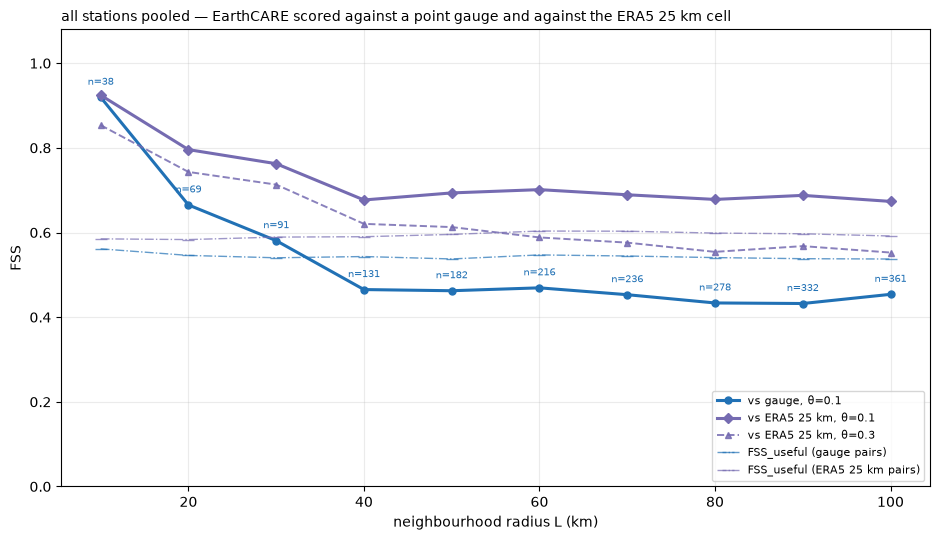

curve,"vs ERA5 25 km, θ=0.1","vs ERA5 25 km, θ=0.3","vs gauge, θ=0.1",useful_gauge,useful_model
L_km,,,,,
10,0.924,0.854,0.920,0.561,0.585
20,0.796,0.743,0.665,0.546,0.583
30,0.763,0.713,0.581,0.540,0.589
40,0.677,0.620,0.465,0.543,0.590
50,0.694,0.613,0.462,0.538,0.596
60,0.701,0.588,0.469,0.547,0.603
70,0.689,0.576,0.453,0.544,0.603
80,0.678,0.554,0.434,0.541,0.599
90,0.688,0.568,0.432,0.538,0.597


In [4]:
from study_config import FSS_RADII    # neighbourhood radii L (km)
FSS_HALF_WINDOW = pd.Timedelta("1h")     # the fixed +/-1 h window


def pooled_pairs(radius_km, theta, reference):
    """Stack the (p_sat, p_ref) pairs of all four stations for one radius:
    the shared fss_pairs with its gauge default, or with the site's ERA5
    series swapped in as the reference -- same overpasses, profiles and
    windows either way."""
    stacks = []
    for site in sites.values():
        reference_kwargs = ({} if reference == "gauge" else dict(
            reference_frame=site["model_hourly"],
            reference_snow=site["model_snow_mmhr"]))
        pairs = fss_pairs(site, radius_km, theta,
                          half_window=FSS_HALF_WINDOW, **reference_kwargs)
        if len(pairs):
            stacks.append(pairs)
    return np.vstack(stacks) if stacks else np.empty((0, 2))


# fss_score comes from src/validation.py -- the same metric section 2 used
# at the point scale, evaluated here over growing neighbourhoods.


# (legend label, theta, reference, line style)
FSS_CONFIGS = [
    (f"vs gauge, θ={THETA_FSS:g}", THETA_FSS, "gauge",
     dict(color=SAT_COLOR, lw=2.2, marker="o", ms=5)),
    (f"vs {MODEL_LABEL}, θ={THETA_FSS:g}", THETA_FSS, "model",
     dict(color=MODEL_COLOR, lw=2.2, marker="D", ms=5)),
    (f"vs {MODEL_LABEL}, θ={THETA_ADJUSTED:g}", THETA_ADJUSTED, "model",
     dict(color=MODEL_COLOR, lw=1.4, ls="--", marker="^", ms=4.5, alpha=0.85)),
]

# --- pooled FSS at every radius for each configuration ---
fss_curves, fss_rows = {}, []
for label, theta, reference, _ in FSS_CONFIGS:
    fss_values, n_pairs, base_rates = [], [], []
    for radius_km in FSS_RADII:
        pooled = pooled_pairs(radius_km, theta, reference)
        fss_values.append(fss_score(pooled))
        n_pairs.append(len(pooled))
        base_rates.append(pooled[:, 1].mean() if len(pooled) else np.nan)
        fss_rows.append(dict(curve=label, L_km=radius_km, n_pairs=len(pooled),
                             FSS=round(fss_values[-1], 3)
                             if np.isfinite(fss_values[-1]) else np.nan))
    fss_curves[label] = dict(fss=fss_values, n=n_pairs, f0=base_rates)

# --- plotting the two references side by side ---
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for label, _, _, style in FSS_CONFIGS:
    ax.plot(FSS_RADII, fss_curves[label]["fss"], label=label, **style)

# one useful-skill line per reference (the gauge and the model have different
# base rates, so each curve is read against its own)
gauge_useful = 0.5 + np.array(fss_curves[f"vs gauge, θ={THETA_FSS:g}"]["f0"]) / 2
model_useful = 0.5 + np.array(fss_curves[f"vs {MODEL_LABEL}, θ={THETA_FSS:g}"]["f0"]) / 2
ax.plot(FSS_RADII, gauge_useful, "-.", color=SAT_COLOR, lw=1, marker="_", ms=8,
        alpha=0.7, label="FSS_useful (gauge pairs)")
ax.plot(FSS_RADII, model_useful, "-.", color=MODEL_COLOR, lw=1, marker="_", ms=8,
        alpha=0.7, label=f"FSS_useful ({MODEL_LABEL} pairs)")

# pair counts (identical for all three curves: theta and reference change the
# values, never whether a pair exists)
for radius_km, fss_value, n in zip(FSS_RADII,
                                   fss_curves[f"vs gauge, θ={THETA_FSS:g}"]["fss"],
                                   fss_curves[f"vs gauge, θ={THETA_FSS:g}"]["n"]):
    if np.isfinite(fss_value):
        ax.annotate(f"n={n}", (radius_km, fss_value), textcoords="offset points",
                    xytext=(0, 9), ha="center", fontsize=7, color=SAT_COLOR)

ax.set_ylim(0, 1.08)
ax.set_xlabel("neighbourhood radius L (km)")
ax.set_ylabel("FSS")
ax.set_title("all stations pooled — EarthCARE scored against a point gauge "
             f"and against the {MODEL_LABEL} cell", loc="left", fontsize=10)
ax.grid(alpha=0.25)
ax.legend(fontsize=8, loc="lower right")
fig.savefig("../figures/model_earthcare_fss.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

# --- the same curves as a table, with both useful-skill references ---
fss_table = (pd.DataFrame(fss_rows).pivot(index="L_km", columns="curve", values="FSS"))
fss_table["useful_gauge"] = np.round(gauge_useful, 3)
fss_table["useful_model"] = np.round(model_useful, 3)
fss_table

## 4 · Satellite, model and gauge at the EarthCARE overpasses

Section 3 asked how the satellite and ERA5 agree *across scales*; this
section fixes the scale and asks **who saw what, overpass by overpass**. The
population is the one scored in `compare_earthcare_dmi_stations` section 2:
every overpass within 100 km of a gauge that has gauge data in the ±30 min
window. For each of them two references say whether it was snowing in that
same window — the gauge (snow-phase precip > 0) and the ERA5 cell (snowfall
> 0 over the stamps overlapping the window, computed with the very same
function) — and the satellite says whether any usable profile was snowing
within 30 km and within 100 km.

Two questions:

1. **Does EarthCARE agree with a 25 km model cell better than with a point
   gauge?** The satellite-vs-gauge rows reproduce the stations notebook; the
   satellite-vs-model rows use the identical overpasses and windows, so any
   change in POD/FAR is a change of *reference*, not of sample. This is the
   single-scale version of the FSS comparison in section 3.
2. **Where do the three disagree?** The eight yes/no patterns per overpass,
   and two short lists of overpasses that are candidates for known failure
   modes — satellite and model snowing while the gauge is dry (undercatch or
   sub-0.1 mm events), and gauge and model snowing while the satellite misses
   — a blind-zone (shallow snow below ~700 m) candidate only if a track
   actually passed within 30 km; otherwise it is geometry, not a miss.

In [5]:
# --- per-overpass flags: gauge and ERA5 in the same +/-30 min window;
#     satellite within 30 km and within 100 km ---
overpass_rows = []
for site_name, site in sites.items():
    scored = site["overpasses"][site["overpasses"].gauge_n_stamps_pm30 > 0]
    for _, overpass in scored.iterrows():
        model_snow_mm, _, _ = snow_window_stats(
            site["model_hourly"], site["model_snow_mmhr"],
            overpass["time"], pd.Timedelta("30min"))
        overpass_rows.append(dict(
            site=site_name, granule=overpass["granule"], time=overpass["time"],
            closest_km=round(float(overpass["closest_km"]), 1),
            gauge=bool(overpass["gauge_snow_pm30_mm"] > 0),
            model=bool(model_snow_mm > 0),
            sat_30km=bool(overpass["sat_any_30km"]),
            sat_100km=bool(overpass["sat_any_100km"])))
overpass_flags = pd.DataFrame(overpass_rows)
REFERENCES = {"gauge": "gauge", "model": MODEL_LABEL}


def contingency_rows(test_col, reference_col, pair_label):
    """Pooled and per-site contingency rows of overpass_flags[test_col]
    against overpass_flags[reference_col]."""
    rows = []
    groups = [("all stations", overpass_flags)] + list(overpass_flags.groupby("site"))
    for group_name, flags in groups:
        counts = contingency(flags[test_col].values, flags[reference_col].values)
        rows.append(dict(pair=pair_label, site=group_name, n=len(flags),
                         ref_events=int(flags[reference_col].sum()), **counts))
    return rows


# --- satellite vs each reference, for both satellite criteria ---
contingency_table = []
for sat_col, sat_label in [("sat_30km", "satellite <=30 km"), ("sat_100km", "satellite <=100 km")]:
    for ref_col, ref_label in REFERENCES.items():
        contingency_table += contingency_rows(sat_col, ref_col, f"{sat_label} vs {ref_label}")
# --- and the model against the gauge in the same windows ---
contingency_table += contingency_rows("model", "gauge", f"{MODEL_LABEL} vs gauge")
contingency_table = pd.DataFrame(contingency_table)

print("pooled over the four stations (same overpasses and windows in every row):")
display(contingency_table[contingency_table.site == "all stations"]
        .drop(columns="site").reset_index(drop=True))
print("per station:")
contingency_table[contingency_table.site != "all stations"].reset_index(drop=True)

pooled over the four stations (same overpasses and windows in every row):


,pair,n,ref_events,hit,miss,false_alarm,correct_neg,POD,FAR
0,satellite <=30 km vs gauge,359,40,9,31,22,297,0.23,0.71
1,satellite <=30 km vs ERA5 25 km,359,66,14,52,17,276,0.21,0.55
2,satellite <=100 km vs gauge,359,40,30,10,177,142,0.75,0.86
3,satellite <=100 km vs ERA5 25 km,359,66,64,2,143,150,0.97,0.69
4,ERA5 25 km vs gauge,359,40,23,17,43,276,0.57,0.65


per station:


,pair,site,n,ref_events,hit,miss,false_alarm,correct_neg,POD,FAR
0,satellite <=30 km vs gauge,aasiaat,118,22,4,18,3,93,0.18,0.43
1,satellite <=30 km vs gauge,ittoqqortoormiit,67,5,0,5,3,59,0.00,1.00
2,satellite <=30 km vs gauge,nuuk,102,9,3,6,11,82,0.33,0.79
3,satellite <=30 km vs gauge,tasiilaq,72,4,2,2,5,63,0.50,0.71
4,satellite <=30 km vs ERA5 25 km,aasiaat,118,13,3,10,4,101,0.23,0.57
5,satellite <=30 km vs ERA5 25 km,ittoqqortoormiit,67,15,2,13,1,51,0.13,0.33
6,satellite <=30 km vs ERA5 25 km,nuuk,102,25,6,19,8,69,0.24,0.57
7,satellite <=30 km vs ERA5 25 km,tasiilaq,72,13,3,10,4,55,0.23,0.57
8,satellite <=100 km vs gauge,aasiaat,118,22,15,7,43,53,0.68,0.74
9,satellite <=100 km vs gauge,ittoqqortoormiit,67,5,4,1,31,31,0.80,0.89


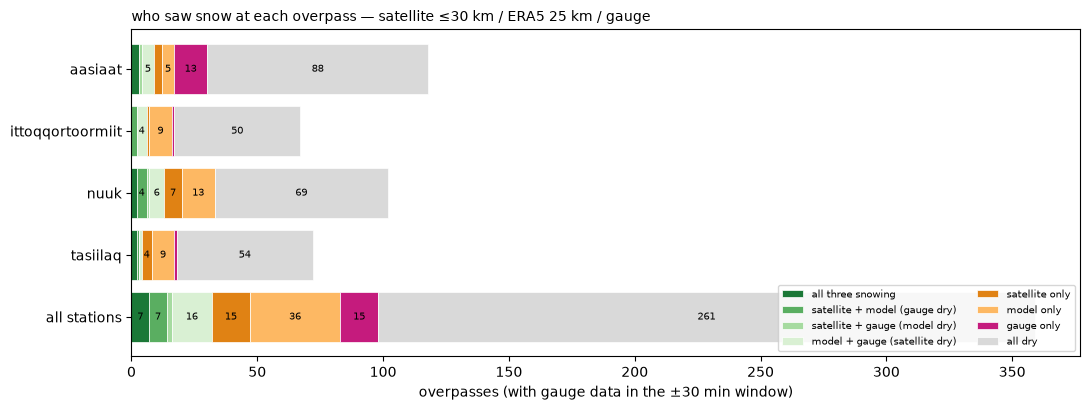

pattern,all three snowing,satellite + model (gauge dry),satellite + gauge (model dry),model + gauge (satellite dry),satellite only,model only,gauge only,all dry
site,,,,,,,,
aasiaat,3,0,1,5,3,5,13,88
ittoqqortoormiit,0,2,0,4,1,9,1,50
nuuk,2,4,1,6,7,13,0,69
tasiilaq,2,1,0,1,4,9,1,54
all stations,7,7,2,16,15,36,15,261


satellite (<=30 km) AND model snowing, gauge dry -- undercatch / sub-0.1 mm candidates:


,site,granule,time,closest_km,sat_30km,sat_100km,model,gauge
0,nuuk,03660B,2025-01-19 04:26:00,11.5,True,True,True,False
1,nuuk,04438B,2025-03-10 04:25:00,11.4,True,True,True,False
2,nuuk,04687B,2025-03-26 04:28:00,24.8,True,True,True,False
3,nuuk,05216B,2025-04-29 04:25:00,11.0,True,True,True,False
4,tasiilaq,08763B,2025-12-13 03:21:00,29.4,True,True,True,False
5,ittoqqortoormiit,05619C,2025-05-25 02:02:00,18.6,True,True,True,False
6,ittoqqortoormiit,08756C,2025-12-12 16:44:00,7.3,True,True,True,False


model AND gauge snowing, no snowing profile <=30 km:
  track within 30 km  -> true blind-zone / shallow-snow candidates: 0
  no track within 30 km -> geometry, not a miss: 16 (detected at <=100 km: 15)


,site,granule,time,closest_km,sat_30km,sat_100km,model,gauge
0,aasiaat,03411C,2025-01-03 04:24:00,60.4,False,True,True,True
1,aasiaat,07668C,2025-10-03 18:35:00,51.7,False,True,True,True
2,aasiaat,07830C,2025-10-14 04:18:00,33.5,False,True,True,True
3,aasiaat,08804C,2025-12-15 18:47:00,55.0,False,True,True,True
4,aasiaat,08888C,2025-12-21 04:10:00,36.9,False,True,True,True
5,nuuk,03411B,2025-01-03 04:23:00,56.7,False,True,True,True
6,nuuk,04229D,2025-02-24 18:17:00,82.1,False,True,True,True
7,nuuk,04578B,2025-03-19 04:21:00,56.9,False,True,True,True
8,nuuk,05396D,2025-05-10 18:16:00,81.2,False,True,True,True
9,nuuk,08437B,2025-11-22 04:31:00,78.1,False,False,True,True


In [6]:
# --- the eight satellite / model / gauge patterns (satellite <=30 km) ---
PATTERN_LABELS = {
    (True, True, True): "all three snowing",
    (True, True, False): "satellite + model (gauge dry)",
    (True, False, True): "satellite + gauge (model dry)",
    (False, True, True): "model + gauge (satellite dry)",
    (True, False, False): "satellite only",
    (False, True, False): "model only",
    (False, False, True): "gauge only",
    (False, False, False): "all dry",
}
PATTERN_COLORS = ["#1b7837", "#5aae61", "#a6dba0", "#d9f0d3",
                  "#e08214", "#fdb863", "#c51b7d", "0.85"]


def pattern_of(flags):
    """Label of the (satellite, model, gauge) yes/no combination of one overpass."""
    return PATTERN_LABELS[(bool(flags["sat_30km"]), bool(flags["model"]),
                           bool(flags["gauge"]))]


overpass_flags["pattern"] = overpass_flags.apply(pattern_of, axis=1)
pattern_order = list(PATTERN_LABELS.values())
pattern_counts = (overpass_flags.groupby(["site", "pattern"]).size()
                  .unstack("pattern").reindex(columns=pattern_order).fillna(0).astype(int))
pattern_counts.loc["all stations"] = pattern_counts.sum()

# --- plotting the patterns as stacked horizontal bars, one per station ---
fig, ax = plt.subplots(figsize=(11, 4.2))
left = np.zeros(len(pattern_counts))
for pattern, color in zip(pattern_order, PATTERN_COLORS):
    counts = pattern_counts[pattern].values
    ax.barh(pattern_counts.index, counts, left=left, color=color, label=pattern,
            edgecolor="white", lw=0.5)
    for y, (x0, n) in enumerate(zip(left, counts)):
        if n >= 4:
            ax.text(x0 + n / 2, y, str(n), ha="center", va="center", fontsize=7.5)
    left += counts
ax.invert_yaxis()
ax.set_xlabel("overpasses (with gauge data in the ±30 min window)")
ax.set_title(f"who saw snow at each overpass — satellite ≤30 km / {MODEL_LABEL} / gauge",
             loc="left", fontsize=10)
ax.legend(fontsize=7.5, ncol=2, loc="lower right")
fig.savefig("../figures/model_earthcare_dmi_overpass_agreement.png", dpi=300,
            bbox_inches="tight")
plt.tight_layout()
plt.show()
display(pattern_counts)

# --- candidate lists for the two known failure modes ---
show_cols = ["site", "granule", "time", "closest_km", "sat_30km", "sat_100km",
             "model", "gauge"]
print("satellite (<=30 km) AND model snowing, gauge dry -- undercatch / sub-0.1 mm candidates:")
display(overpass_flags[overpass_flags.pattern == "satellite + model (gauge dry)"][show_cols]
        .reset_index(drop=True))
# a satellite "miss" at <=30 km is only a blind-zone candidate if a track
# actually passed within 30 km; otherwise it is geometry, not a miss
missed = overpass_flags[overpass_flags.pattern == "model + gauge (satellite dry)"]
track_within_30 = missed.closest_km <= 30
print("model AND gauge snowing, no snowing profile <=30 km:")
print(f"  track within 30 km  -> true blind-zone / shallow-snow candidates: "
      f"{int(track_within_30.sum())}")
print(f"  no track within 30 km -> geometry, not a miss: {int((~track_within_30).sum())} "
      f"(detected at <=100 km: {int(missed[~track_within_30].sat_100km.sum())})")
display(missed[show_cols].reset_index(drop=True))

## 5 · Takeaways

- **Hour by hour, ERA5 and the gauge agree only loosely, and Aasiaat is the
  odd one out.** At the exact hour the ERA5 cell scores POD 0.69–0.76 with
  FAR 0.64–0.76 at Nuuk, Tasiilaq and Ittoqqortoormiit, but only **POD 0.35 /
  FAR 0.61 at Aasiaat** — where the elevation-matched land cell sits **23.5 km**
  from the station, the largest offset of the four (the others are 2.5–16.3 km).
  Pooled over all 29 171 scored hours: POD 0.60, FAR 0.69, frequency bias 1.94.
- **At the point scale the pair never reaches useful skill, and the ±1 h
  tolerance makes it worse.** Point FSS is 0.34–0.49 per station against a
  useful-skill line of 0.52–0.54 (pooled 0.408 vs 0.532). Allowing an hour of
  timing slack raises pooled POD from 0.60 to 0.65 but *lowers* FSS to 0.391,
  at every station — it buys hits with disproportionately more false alarms
  (2 505 → 3 111). So the hourly disagreement is not an hour of timing error;
  forgiving timing does not repair it.
- **The model snows far more often than the gauge registers — except at
  Aasiaat.** Frequency bias 0.89 at Aasiaat but **2.1–2.9** at the other
  three. The same split shows in snow water over the gauge-valid hours: ERA5
  carries **0.80×** the gauge's total at Aasiaat and **0.96×** at Nuuk, but
  **2.04×** at Tasiilaq and **2.42×** at Ittoqqortoormiit. The west-coast
  pairs sit inside the undercatch band (60–90 % catch at ~5 m/s; Kochendorfer
  et al. 2017); the east-coast pairs do not, so cell-versus-point averaging
  and wind undercatch compound there.
- **Aggregating to whole days is what recovers skill.** Pooled POD 0.68 /
  FAR 0.30, and **pooled FSS 0.690 against a useful-skill line of 0.651** —
  the daily pair clears the bar the hourly pair missed, and it does so
  against a *harder* bar, since aggregation lifts the gauge's base rate from
  0.06 of hours to 0.30 of days (FSS_useful 0.532 → 0.651). Per station Nuuk
  (0.803 vs 0.661) and Tasiilaq (0.667 vs 0.599) clear it, Ittoqqortoormiit
  sits exactly on it (0.603 vs 0.607), and Aasiaat is the only one clearly
  below (0.630 vs 0.716) — again the station with the 23.5 km cell offset,
  where POD is 0.49 but FAR only 0.12: it rarely invents snow days, it
  displaces them. Read together with the ±1 h result above, the displacement
  between model and gauge is **longer than an hour but shorter than a day**,
  which is why an hour of slack does not help and a day of aggregation
  does.
- **The headline: changing the reference from a point gauge to a 25 km cell
  removes most of EarthCARE's apparent scale decay.** Scored against the
  gauge, pooled FSS falls from 0.920 at 10 km to **0.454** at 100 km and
  drops below useful skill past ~30 km — the stations-notebook result.
  Scored against ERA5 on the *identical* overpasses, profiles and windows, it
  goes 0.924 at 10 km to **0.673** at 100 km and stays **above its own
  useful-skill line at every radius**, flat at 0.67–0.70 from 40 km out. The
  ERA5 bar is the harder one (base rate f₀ ≈ 0.17–0.21 against the gauge's
  0.07–0.12, so FSS_useful ≈ 0.59 vs 0.54) and the satellite still clears it.
  **So a large part of what section 3 of the stations notebook read as
  satellite decorrelation beyond 30 km was the gauge's own point
  representativeness, not the satellite disagreeing about the weather.**
- **The θ = 0.3 sublimation adjustment does not survive the change of
  reference.** Against the gauge it raised FSS at short range; against ERA5
  it is **worse at every single radius** (0.854 vs 0.924 at 10 km, 0.553 vs
  0.673 at 100 km) and falls below useful skill past ~50 km. The reading:
  much of the light aloft-snow that θ = 0.3 deletes is snow an independent
  areal product also reports — real precipitation the point gauge cannot
  measure at its 0.1 mm floor — rather than virga that sublimates away. This
  does not refute the sublimation argument (ERA5 is not truth, and it carries
  a 2.0–2.4× wet bias at the east-coast sites), but it does show the θ = 0.3
  gain is a property of the gauge reference, and it should not be promoted to
  a general correction on this evidence.
- **The same reference swap at overpass level.** On the identical 359
  windows, the ≤100 km criterion goes from POD 0.75 / FAR 0.86 against the
  gauge to **POD 0.97 / FAR 0.69** against ERA5 — EarthCARE almost never
  misses a window in which the model cell snows (64 of 66). At ≤30 km it
  barely moves (POD 0.23→0.21, FAR 0.71→0.55): too few tracks come that
  close for the reference to matter. In the same windows the model itself
  scores **POD 0.57 / FAR 0.65** against the gauge — a 25 km cell sitting on
  the station agrees with the gauge about as well as the satellite does at
  100 km. That is the ceiling a point gauge imposes on any areal product at
  hourly resolution.
- **Who saw snow.** 261 of 359 windows are dry for all three. The model is by
  far the most frequent lone voice (**36** "model only" vs 15 satellite-only
  and 15 gauge-only). When model *and* gauge both snow (23 windows) the
  satellite confirms 7 within 30 km — and **all 16 "misses" have a closest
  approach of 33–89 km**: no track passed within 30 km, and 15 of the 16 are
  detected at ≤100 km. There is not a single window with a track inside
  30 km where the satellite missed snow that both other sources saw, so the
  blind-zone hypothesis for the ≤30 km misses again finds no support.
- **Seven candidate windows for gauge undercatch**, where the satellite
  (≤30 km) and ERA5 both snow while the gauge is dry, at closest approach
  7–29 km (Nuuk ×4, Ittoqqortoormiit ×2, Tasiilaq ×1) — the best cases for
  sub-0.1 mm or wind-blown snow the gauge did not catch.
- **Caveats.** One elevation-matched land cell per station, 2.5–23.5 km away
  (neighbouring cells differ by up to ~27 % in annual snow, and Aasiaat's
  23.5 km offset is a plausible cause of its outlier scores); 0.1 mm
  quantization on both sides; the model uses its own phase scheme while the
  gauge uses the T ≤ 1.5 °C proxy; and ERA5 at 25 km is a *coarser* areal
  average than the ~1 km curtain it is being compared to, so agreement with
  it is a weaker claim than agreement with a truly independent 2.5 km product
  would be. CARRA2 remains the natural next reference.

## References

- Hersbach, H., et al. (2020). The ERA5 global reanalysis. *Q. J. R.
  Meteorol. Soc.*, 146, 1999–2049. doi:10.1002/qj.3803
- Roberts, N. M., & Lean, H. W. (2008). Scale-selective verification of
  rainfall accumulations from high-resolution forecasts of convective events.
  *Mon. Wea. Rev.*, 136, 78–97. doi:10.1175/2007MWR2123.1
- Mittermaier, M. P. (2014). A strategy for verifying near-convection-
  resolving forecasts at observing sites. *Wea. Forecasting*, 29, 185–204.
  doi:10.1175/WAF-D-12-00075.1
- Kochendorfer, J., et al. (2017). Analysis of single-Alter-shielded and
  unshielded measurements of mixed and solid precipitation from WMO-SPICE.
  *Hydrol. Earth Syst. Sci.*, 21, 3525–3542. doi:10.5194/hess-21-3525-2017
- Fettweis, X., et al. (2017). Reconstructions of the 1900–2015 Greenland ice
  sheet surface mass balance using the regional climate MAR model.
  *The Cryosphere*, 11, 1015–1033. doi:10.5194/tc-11-1015-2017
- Noël, B., et al. (2018). Modelling the climate and surface mass balance of
  polar ice sheets using RACMO2 – Part 1: Greenland (1958–2016).
  *The Cryosphere*, 12, 811–831. doi:10.5194/tc-12-811-2018
- Open-Meteo Historical Weather API documentation,
  https://open-meteo.com/en/docs/historical-weather-api (ERA5 archive;
  `cell_selection`, hour-end stamping, 0.1 mm precision).
- Illingworth, A. J., et al. (2015). The EarthCARE satellite. *Bull. Amer.
  Meteor. Soc.*, 96, 1311–1332. doi:10.1175/BAMS-D-12-00227.1